In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *
from lightgbm import LGBMClassifier

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [37]:
from dcr import *  

_, data_train_LGD, data_test_LGD, X_train_scaled_LGD, X_test_scaled_LGD, y_train_LGD, y_test_LGD = dataprep(data,  depvar='lgd_time', splitvar='time', threshold=40)

In [38]:
print('Shape train data:', X_train_scaled_LGD.shape)  
print('Shape test data:', X_test_scaled_LGD.shape)  
print('Default rate train data:', np.mean(y_train_LGD).round(4))  
print('Default rate test data:', np.mean(y_test_LGD).round(4))

Shape train data: (1147, 56)
Shape test data: (377, 44)
Default rate train data: 0.6158
Default rate test data: 0.6468


In [39]:
X_train_linreg = sm.add_constant(X_train_scaled_LGD, prepend=True)

linear_model = sm.OLS(y_train_LGD, X_train_linreg)
result_linreg = linear_model.fit()

print(result_linreg.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.244
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     6.286
Date:                Sat, 23 Aug 2025   Prob (F-statistic):           2.74e-37
Time:                        17:19:56   Log-Likelihood:                -113.45
No. Observations:                1147   AIC:                             340.9
Df Residuals:                    1090   BIC:                             628.5
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6360      0.124      5.138      0.0

In [40]:
model_linreg = LinearRegression()

model_linreg.fit(X_train_scaled_LGD, y_train_LGD)

print('Coefficients:', model_linreg.coef_.round(decimals=4))
print('Intercept:', model_linreg.intercept_.round(decimals=4))

Coefficients: [-0.0034 -0.088   0.035   0.0027 -0.0018 -0.0199 -0.0147 -0.0148 -0.1339
 -0.0152 -0.0524 -0.2234 -0.055  -0.1446 -0.1842  0.1016 -0.082   0.1553
 -0.3657 -0.31    0.0915  0.0878 -0.1915  0.062  -0.0028 -0.0916 -0.0046
  0.141   0.1276 -0.0986 -0.0452 -0.0486 -0.1616 -0.1659 -0.4631  0.1657
  0.0397 -0.0197  0.0055  0.0337  0.1598  0.0741 -0.1494 -0.0149 -0.5072
 -0.1168  0.0264 -0.061  -0.1686 -0.1052 -0.2629 -0.1989 -0.244   0.1365
  0.1174 -0.6059]
Intercept: 0.636


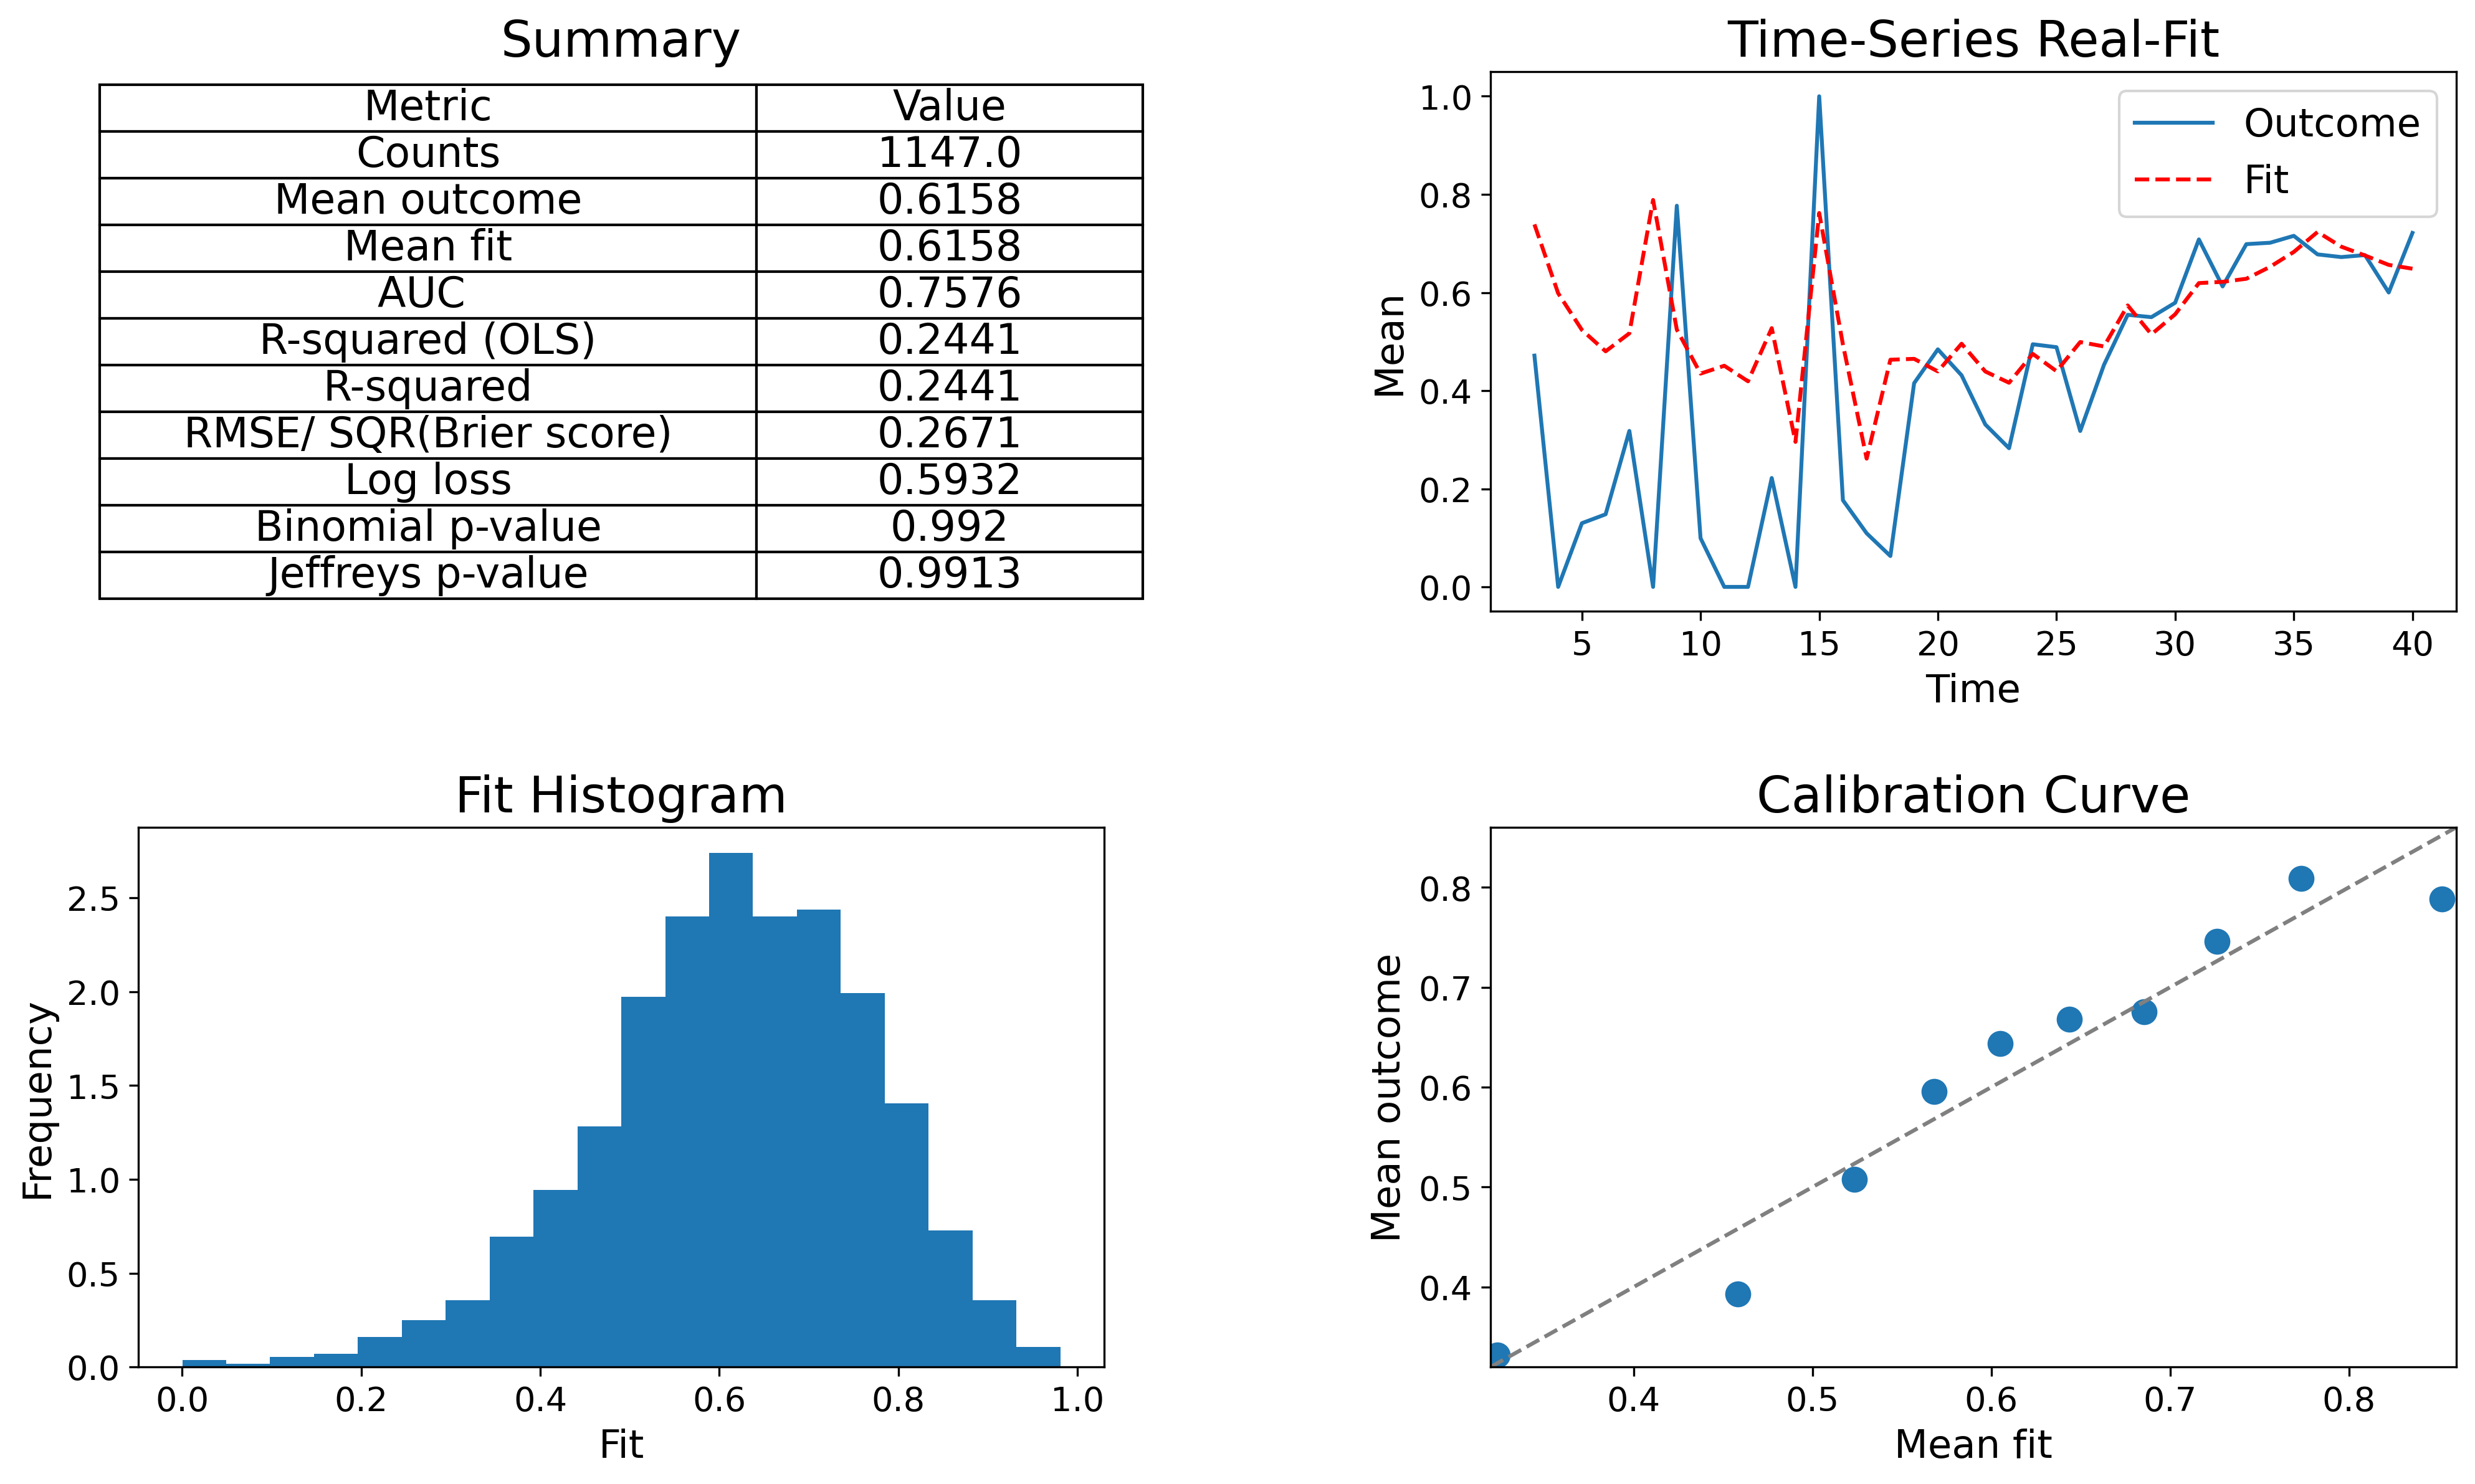

In [41]:
predictions_train = model_linreg.predict(X_train_scaled_LGD)

validation(predictions_train, y_train_LGD, data_train_LGD['time'].values, continuous=True)

In [42]:
predictions_test = model_linreg.predict(X_test_scaled_LGD)

predictions_test = np.maximum(predictions_test, 0.0001)
predictions_test = np.minimum(predictions_test, 0.9999)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)
RMSE_linreg = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but LinearRegression is expecting 56 features as input.

In [43]:
model_ridge = Ridge(alpha=2000)
model_ridge.fit(X_train_scaled_LGD, y_train_LGD)

print('Coefficients:', model_ridge.coef_.round(decimals=4))
print('Intercept:', model_ridge.intercept_.round(decimals=4))

Coefficients: [-0.001  -0.0305  0.0122  0.0017  0.0009 -0.0093 -0.018   0.     -0.0002
  0.0002 -0.0034 -0.0021 -0.0001 -0.0002 -0.0003  0.0089 -0.0013  0.0007
 -0.0006 -0.0003  0.0025  0.0009 -0.0002  0.0002  0.0001 -0.0007  0.0003
  0.0005  0.0025 -0.0011 -0.     -0.     -0.0001 -0.0017 -0.0005  0.0002
  0.0008 -0.      0.0005  0.0011  0.0034  0.0002 -0.0009  0.0001 -0.0003
 -0.0001  0.0004 -0.     -0.0013 -0.0017 -0.0011 -0.0021 -0.0034  0.0007
  0.0002 -0.0003]
Intercept: 0.6154


In [44]:
#X_test_scaled_LGD = X_test_scaled_LGD[:, 44]
predictions_test = model_ridge.predict(X_test_scaled_LGD)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)
RMSE_ridge = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but Ridge is expecting 56 features as input.

In [45]:
X_test_scaled_LGD.shape

(377, 44)

In [47]:
params_ridge = {'alpha': [0.1, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 
10000]}

print(params_ridge)

model_ridge = Ridge()

gs_ridge = GridSearchCV(model_ridge, params_ridge, verbose=1, n_jobs=2, cv=5, scoring = 'neg_root_mean_squared_error')
gs_ridge.fit(X_train_scaled_LGD, y_train_LGD)

print(gs_ridge.best_params_)
print(gs_ridge.best_score_)

# save the model to disk
filename = 'Mortgage_ridge_LGD_GridSearch.sav'
pickle.dump(gs_ridge, open(filename, 'wb'))

{'alpha': [0.1, 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]}
Fitting 5 folds for each of 14 candidates, totalling 70 fits
{'alpha': 10}
-0.2898235755201416


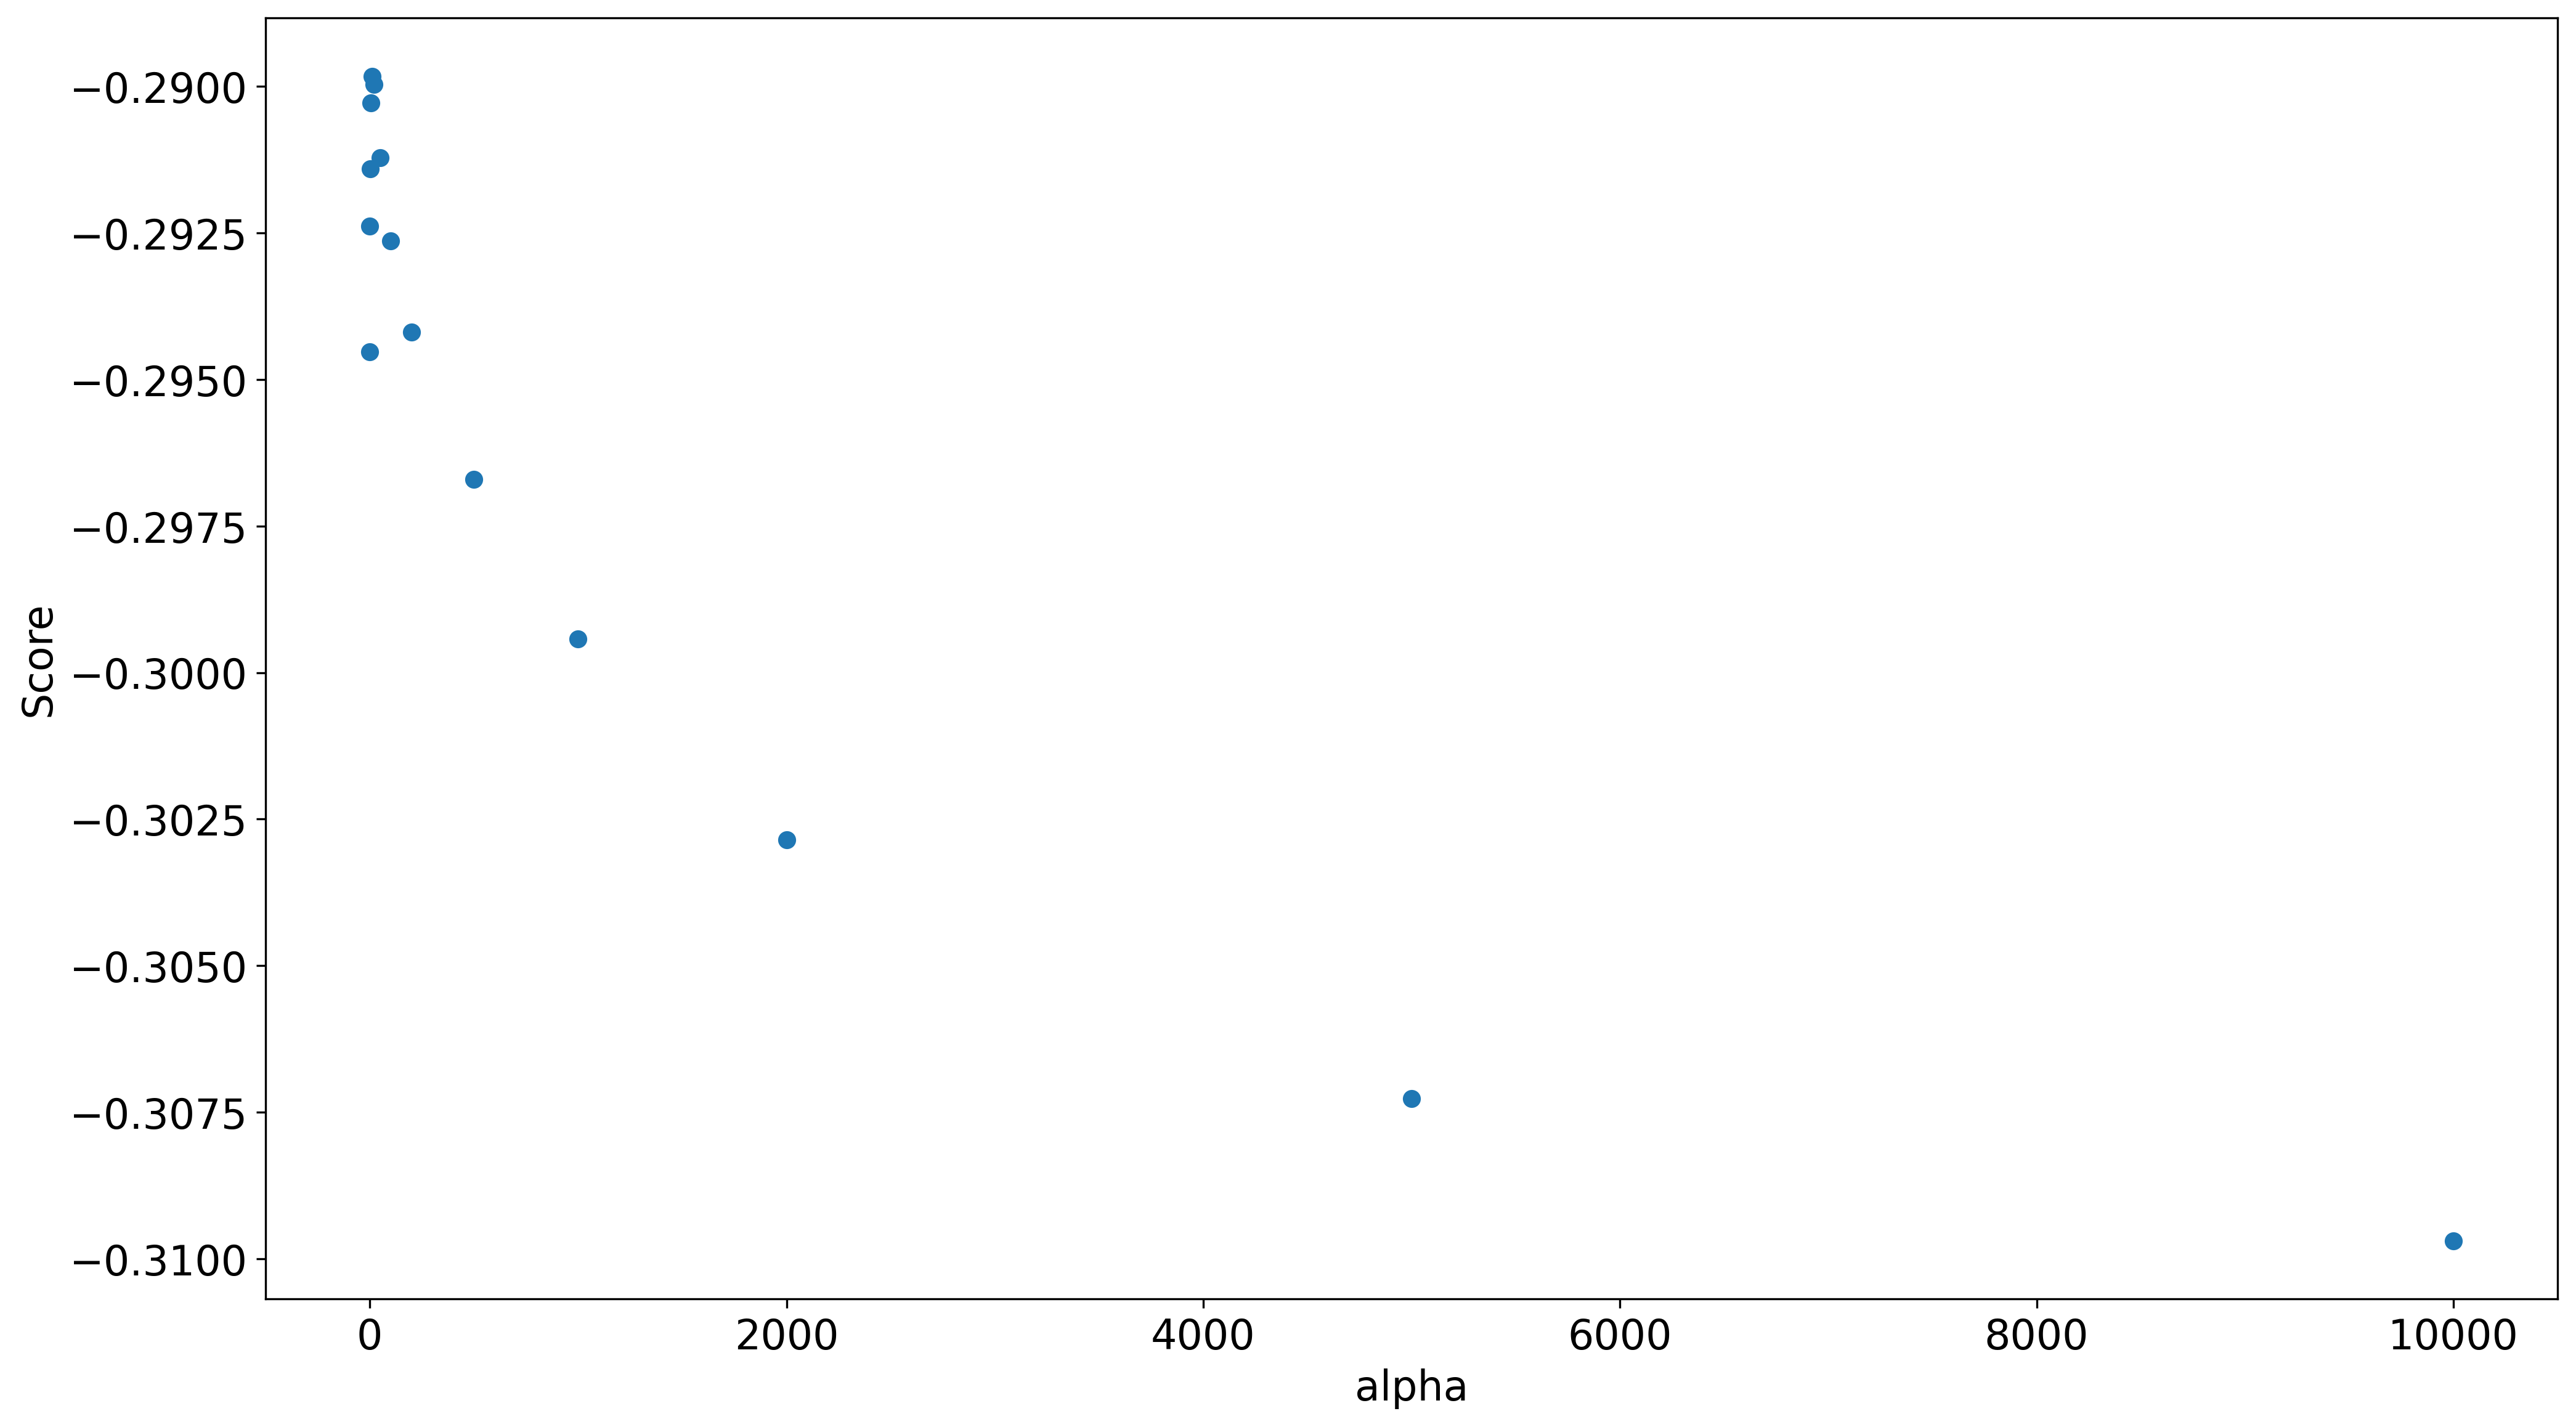

In [48]:
plt.plot(pd.DataFrame(gs_ridge.cv_results_.get('params')).iloc[:,0], gs_ridge.cv_results_['mean_test_score'], marker='o', linestyle='')
plt.ylabel('Score')
plt.xlabel('alpha')
plt.show()

In [49]:
filename = 'Mortgage_ridge_LGD_GridSearch.sav'
gs_ridge = pickle.load(open(filename, 'rb'))
model_ridge_best = Ridge(alpha = gs_ridge.best_params_.get('alpha'))

model_ridge_best.fit(X_train_scaled_LGD, y_train_LGD)

Ridge(alpha=10)

In [50]:
predictions_test = model_ridge_best.predict(X_test_scaled_LGD)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)

RMSE_ridge_best = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but Ridge is expecting 56 features as input.

In [53]:
model_lasso = Lasso(alpha=0.01, copy_X=True, fit_intercept=True, max_iter=1000, positive=False, precompute=False, random_state=None, selection='cyclic', tol=0.0001, warm_start=False)

model_lasso.fit(X_train_scaled_LGD, y_train_LGD)

print('Coefficients:', model_lasso.coef_.round(decimals=4))
print('Intercept:', model_lasso.intercept_.round(decimals=4))

Coefficients: [-0.     -0.0846  0.0321 -0.      0.     -0.015  -0.0089  0.     -0.
  0.     -0.     -0.     -0.     -0.     -0.      0.0532 -0.      0.
 -0.     -0.      0.      0.     -0.      0.      0.     -0.      0.
  0.      0.     -0.     -0.     -0.     -0.     -0.     -0.      0.
  0.      0.      0.      0.      0.      0.     -0.      0.     -0.
 -0.      0.     -0.     -0.     -0.     -0.     -0.     -0.      0.
  0.     -0.    ]
Intercept: 0.6088


In [54]:
predictions_test = model_lasso.predict(X_test_scaled_LGD)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)
RMSE_lasso = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but Lasso is expecting 56 features as input.

In [55]:
params_lasso = {'alpha': [0.001, 0.01, 0.1, 0.2, 0.5, 0.8, 1, 1.5, 2, 5, 10, 50]}

print(params_lasso)

model_lasso = Lasso()

gs_lasso = GridSearchCV(model_lasso, params_lasso, verbose=1, n_jobs=2, cv=5, scoring = 'neg_root_mean_squared_error')
gs_lasso.fit(X_train_scaled_LGD, y_train_LGD)

print(gs_lasso.best_params_)
print(gs_lasso.best_score_)

# save the model to disk
filename = 'Mortgage_lasso_LGD_GridSearch.sav'
pickle.dump(gs_lasso, open(filename, 'wb'))

{'alpha': [0.001, 0.01, 0.1, 0.2, 0.5, 0.8, 1, 1.5, 2, 5, 10, 50]}
Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'alpha': 0.001}
-0.29091418199235497


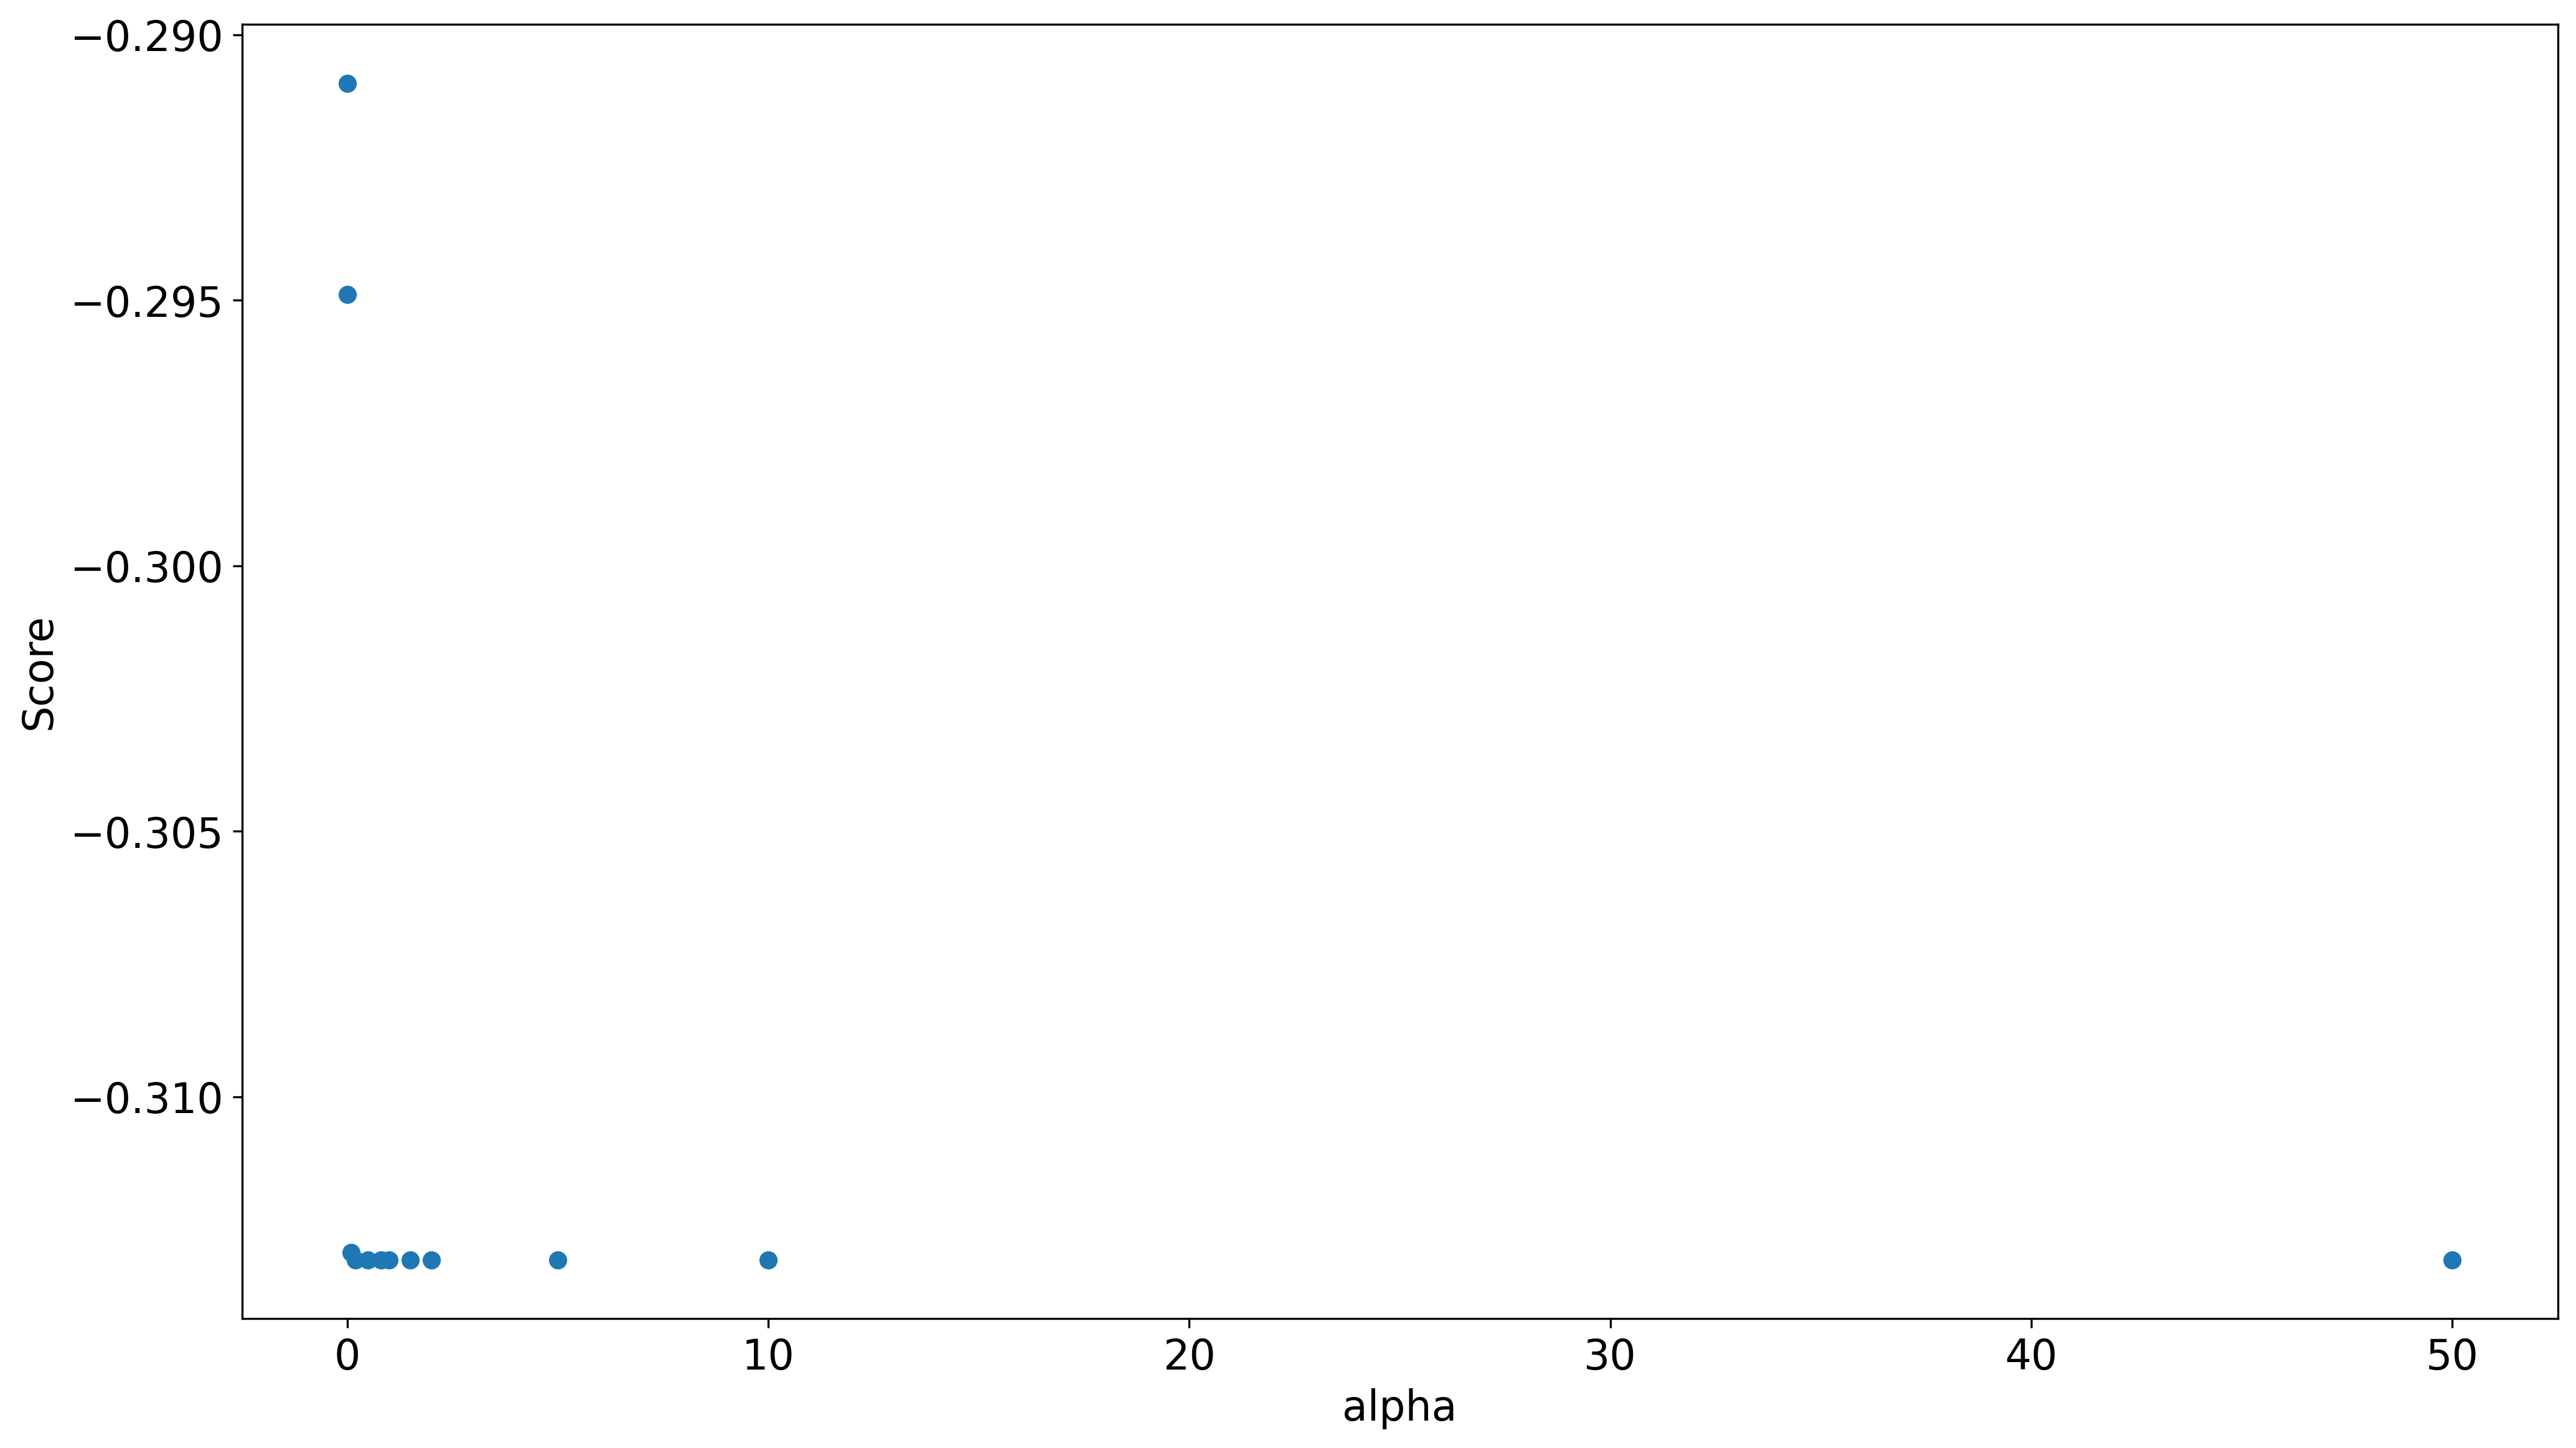

In [56]:
plt.plot(pd.DataFrame(gs_lasso.cv_results_.get('params')).iloc[:,0], gs_lasso.cv_results_['mean_test_score'], marker='o', linestyle='')
plt.ylabel('Score')
plt.xlabel('alpha')
plt.show()


In [59]:
filename = 'Mortgage_lasso_LGD_GridSearch.sav'
gs_lasso = pickle.load(open(filename, 'rb'))
model_lasso_best = Lasso(alpha = gs_lasso.best_params_.get('alpha'), copy_X=True,
                         fit_intercept=True, max_iter=1000,
                         positive=False, precompute=False, random_state=None,
                         selection='cyclic', tol=0.0001, warm_start=False)

model_lasso_best.fit(X_train_scaled_LGD, y_train_LGD)

Lasso(alpha=0.001)

In [60]:
predictions_test = model_lasso_best.predict(X_test_scaled_LGD)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)
RMSE_lasso_best = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but Lasso is expecting 56 features as input.

In [61]:
n_neighbors = 500
model_knn = KNeighborsRegressor(n_neighbors, weights='uniform')
model_knn.fit(X_train_scaled_LGD, y_train_LGD)

KNeighborsRegressor(n_neighbors=500)

In [62]:
predictions_test = model_knn.predict(X_test_scaled_LGD)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)
RMSE_knn = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but KNeighborsRegressor is expecting 56 features as input.

In [64]:
params_knn = {'n_neighbors': 2**(np.arange(0,10,1))}

print(params_knn)

model_knn_gs = KNeighborsRegressor()

gs_knn = GridSearchCV(model_knn_gs, params_knn, verbose=1, n_jobs=2, cv=5, scoring = 'neg_root_mean_squared_error')
gs_knn.fit(X_train_scaled_LGD, y_train_LGD)

print(gs_knn.best_params_)
print(gs_knn.best_score_)

filename = 'Mortgage_knn_LGD_GridSearch.sav'
pickle.dump(gs_knn, open(filename, 'wb'))

{'n_neighbors': array([  1,   2,   4,   8,  16,  32,  64, 128, 256, 512], dtype=int32)}
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'n_neighbors': 32}
-0.2909894016320604


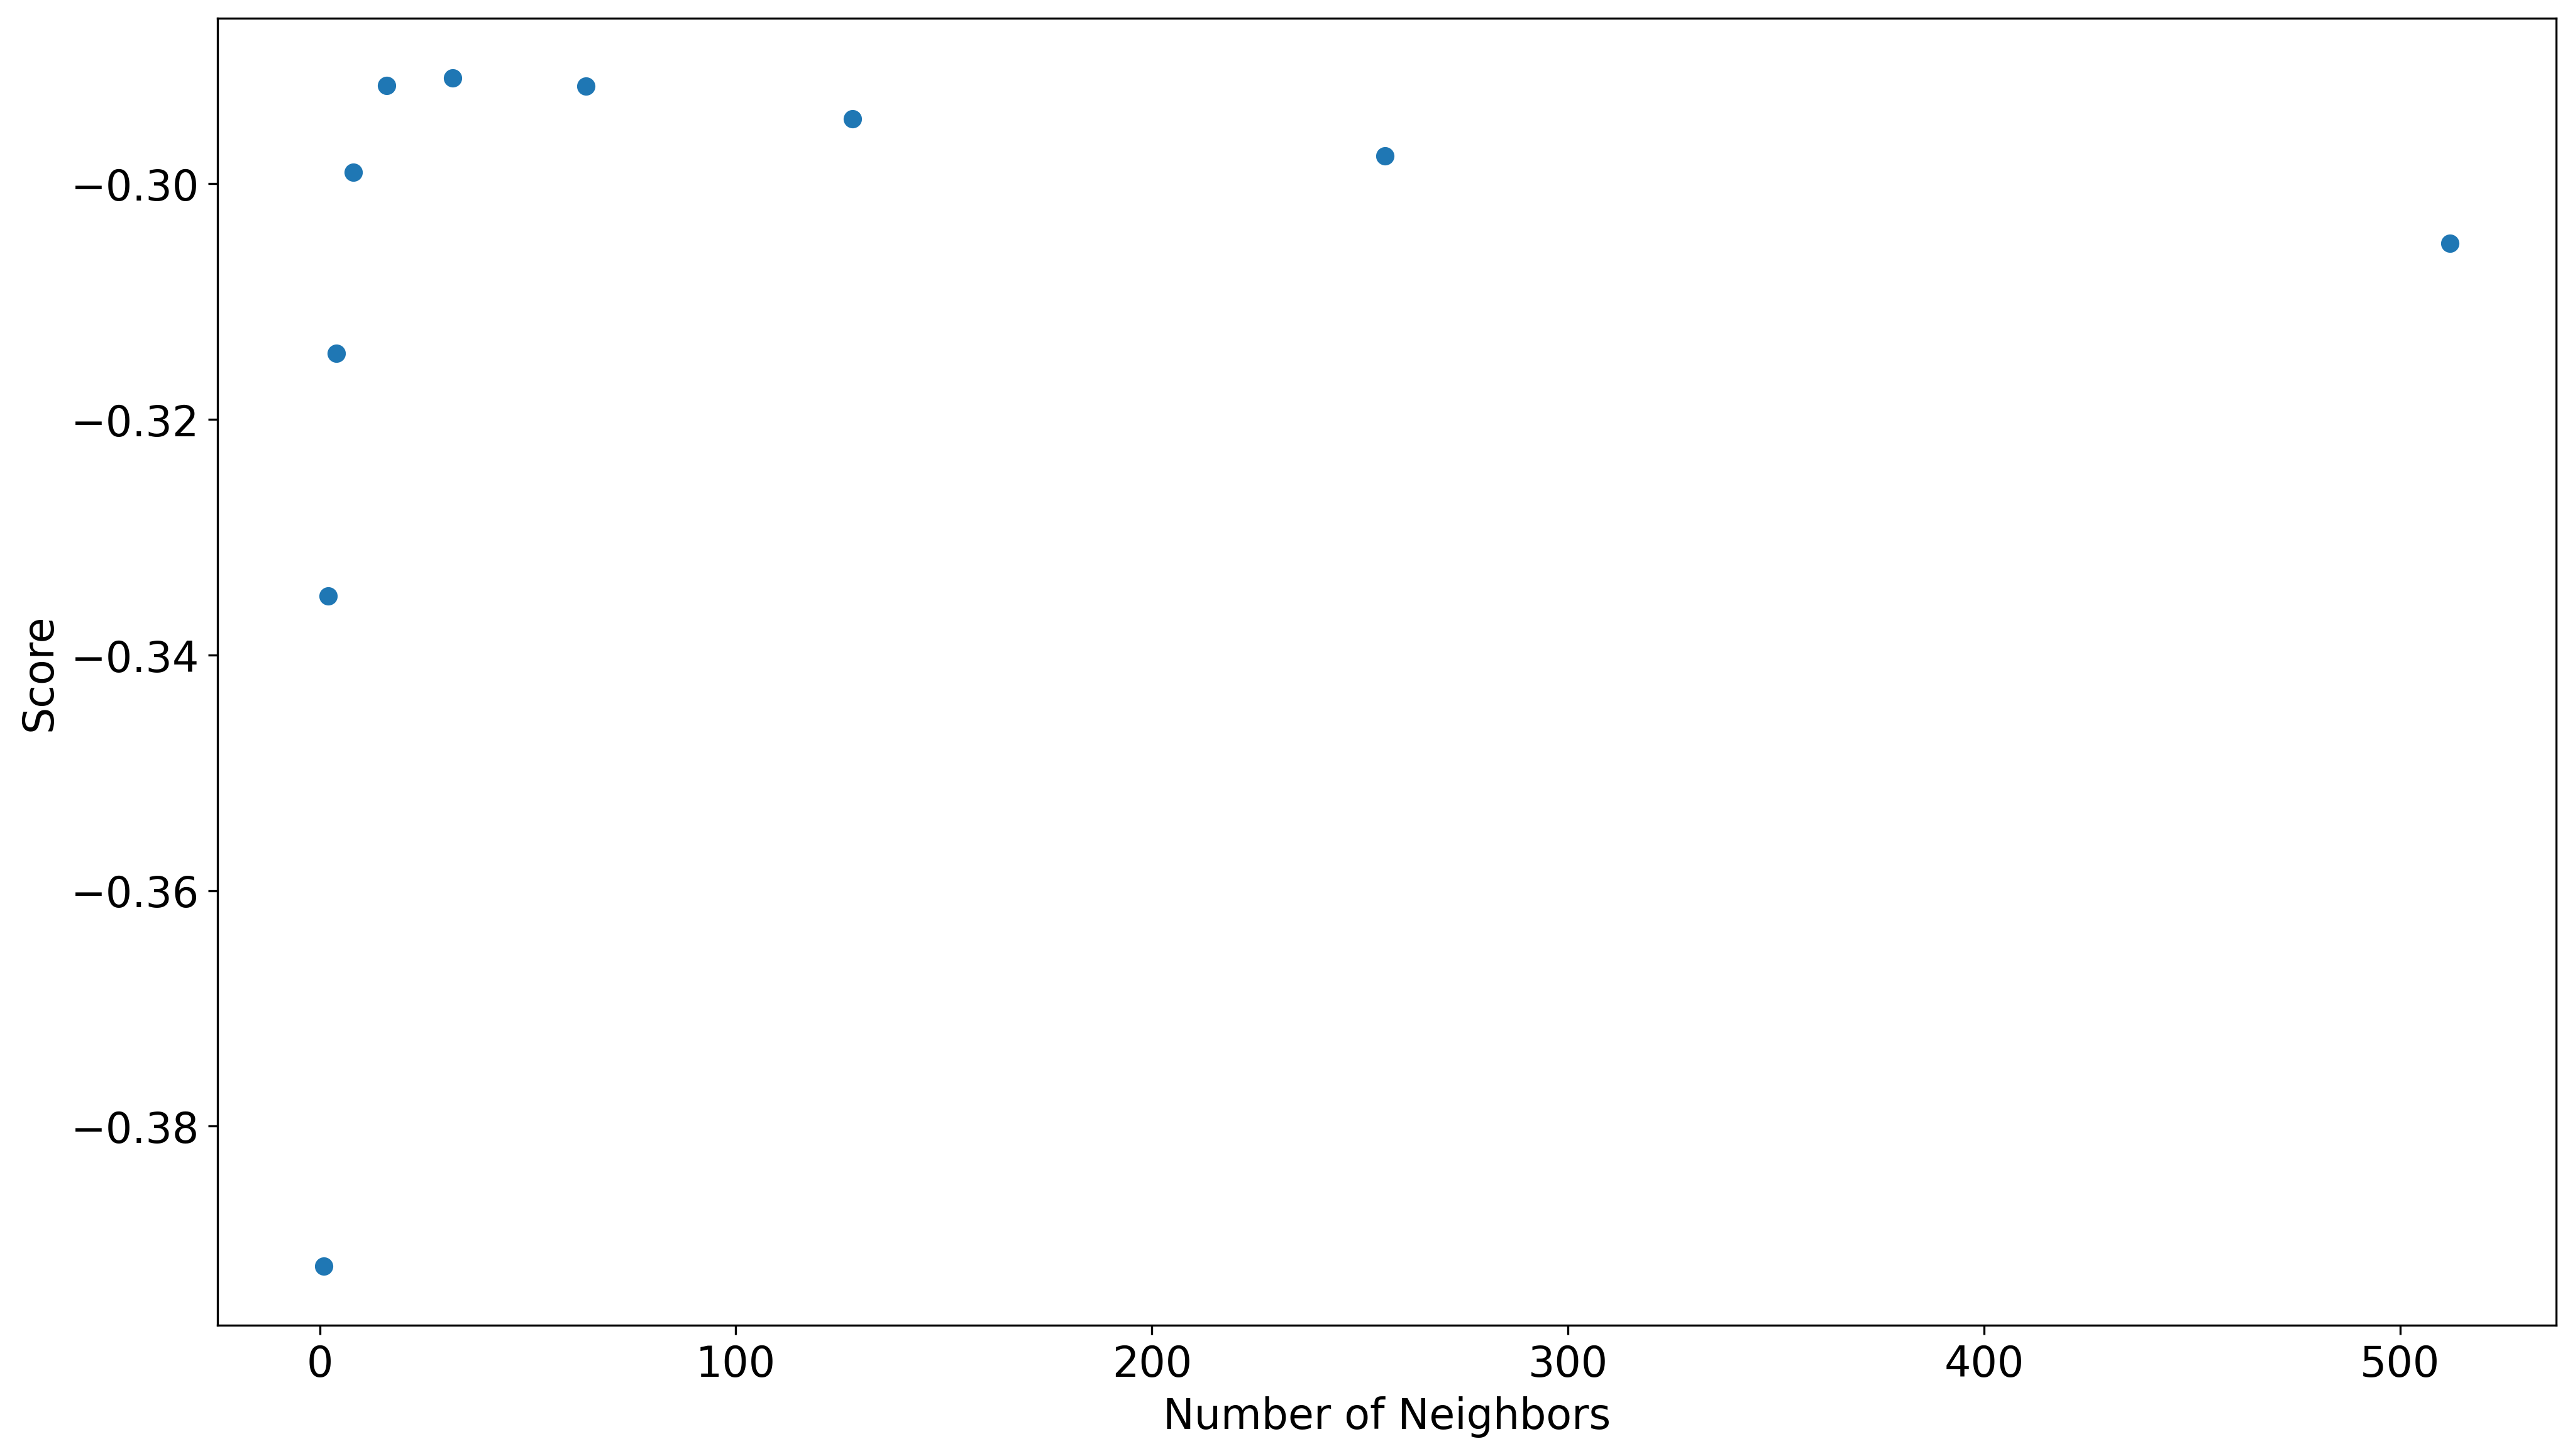

In [65]:
plt.plot(pd.DataFrame(gs_knn.cv_results_.get('params')).iloc[:,0], gs_knn.cv_results_['mean_test_score'], marker='o', linestyle='')
plt.ylabel('Score')
plt.xlabel('Number of Neighbors')
plt.show()

In [66]:
filename = 'Mortgage_knn_LGD_GridSearch.sav'
gs_knn = pickle.load(open(filename, 'rb'))
model_knn_best = KNeighborsRegressor(n_neighbors = gs_knn.best_params_.get('n_neighbors'))

model_knn_best.fit(X_train_scaled_LGD, y_train_LGD)

KNeighborsRegressor(n_neighbors=32)

In [67]:
predictions_test = model_knn_best.predict(X_test_scaled_LGD)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)
RMSE_knn_best = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but KNeighborsRegressor is expecting 56 features as input.

In [68]:
model_dt = DecisionTreeRegressor(random_state=0, max_depth=5, max_features=5)
model_dt.fit(X_train_scaled_LGD, y_train_LGD)

DecisionTreeRegressor(max_depth=5, max_features=5, random_state=0)

In [69]:
predictions_test = model_dt.predict(X_test_scaled_LGD)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)
RMSE_dt = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but DecisionTreeRegressor is expecting 56 features as input.

In [73]:
np.random.seed(seed=123456)
params_dt = { "max_depth": sp_randint(1, 5),
              "max_features": sp_randint(1, 7),
              "min_samples_split": sp_randint(2, 5)}

model_dt_gs = DecisionTreeRegressor(random_state=123456)

rs_dt = RandomizedSearchCV(model_dt_gs, params_dt, verbose=2, random_state=123456, n_iter=5000, n_jobs=2, cv=5, refit=True, scoring = 'neg_root_mean_squared_error')
rs_dt.fit(X_train_scaled_LGD, y_train_LGD)

print(rs_dt.best_params_)
filename = 'Mortgage_dt_LGD_RandomizedGridSearch.sav'
pickle.dump(rs_dt, open(filename, 'wb'))

Fitting 5 folds for each of 5000 candidates, totalling 25000 fits
{'max_depth': 3, 'max_features': 6, 'min_samples_split': 2}


In [74]:
filename = 'Mortgage_dt_LGD_RandomizedGridSearch.sav'
rs_dt = pickle.load(open(filename, 'rb'))

model_dt_best = DecisionTreeRegressor(random_state=123456, max_depth = rs_dt.best_params_.get('max_depth'),
                                       max_features = rs_dt.best_params_.get('max_features'),
                                       min_samples_split = rs_dt.best_params_.get('min_samples_split'))

model_dt_best.fit(X_train_scaled_LGD, y_train_LGD)
print(model_dt_best.feature_importances_.round(decimals=4))

[0.     0.8443 0.     0.0609 0.     0.     0.     0.     0.     0.
 0.0525 0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.0423 0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.    ]


In [75]:
predictions_test = model_dt_best.predict(X_test_scaled_LGD)

validation(predictions_test, y_test_LGD, data_test_LGD['time'].values, continuous=True)
RMSE_dt_best = np.sqrt(mean_squared_error(predictions_test, y_test_LGD)).round(4)

ValueError: X has 44 features, but DecisionTreeRegressor is expecting 56 features as input.

In [76]:
export_graphviz(model_dt_best,
                out_file='model_dt_LGD.dot',
                rounded=False, filled=True)

(graph,) = pydot.graph_from_dot_file('model_dt_LGD.dot')
graph.write_png('model_dt_LGD.png')

from IPython.display import Image  # Plotting .png
Image(filename = 'model_dt_LGD.png')

NameError: name 'pydot' is not defined